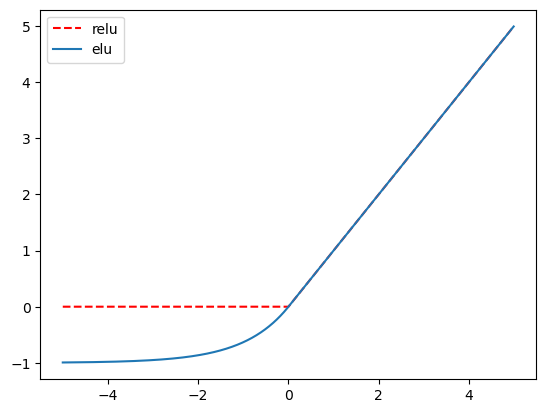

In [1]:
# 오토인코더 => 입력데이터 복제를 위해 훈련되는 딥러닝
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-5, 5, 0.01)
relu = [0 if z < 0 else z for z in x]
elu = [1.0*(np.exp(z) - 1) if z < 0 else z for z in x]

plt.plot(x, relu, 'r--', label="relu")
plt.plot(x, elu, label="elu")
plt.legend()
plt.show()

In [2]:
import tensorflow as tf

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train.shape, x_test.shape, 

((60000, 28, 28), (10000, 28, 28))

In [ ]:
! pip install -U protobuf

In [3]:
# 정규화 

x_train_scaled = x_train / 255.0
x_test_scaled = x_test / 255.0

In [ ]:
from tensorflow.keras import layers

# Dense를 이용한 복원
model = tf.keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(784, activation="elu"),
    layers.Dense(64, activation="elu"),
    layers.Dense(784, activation="sigmoid"),
    layers.Reshape((28,28))
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 716,640 (2.73 MB)

 Trainable params: 716,640 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 회귀모델 컴파일
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [9]:
model.fit(x_train_scaled, x_train_scaled, epochs=30)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0213 - mae: 0.0580
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0114 - mae: 0.0360
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0095 - mae: 0.0317
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0084 - mae: 0.0290
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0077 - mae: 0.0275
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0074 - mae: 0.0267
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0071 - mae: 0.0261
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0068 - mae: 0.0254
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0066 - mae: 0.0250
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0063 - mae: 0.0244
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0062 - mae: 0.0240
Epoch 12/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0061 - mae: 0.0238
E

In [11]:
from sklearn.metrics import r2_score

pred = model.predict(x_test_scaled)

r2 = r2_score(x_test_scaled.reshape(784, -1), pred.reshape(784,-1))
r2

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.94709805995103

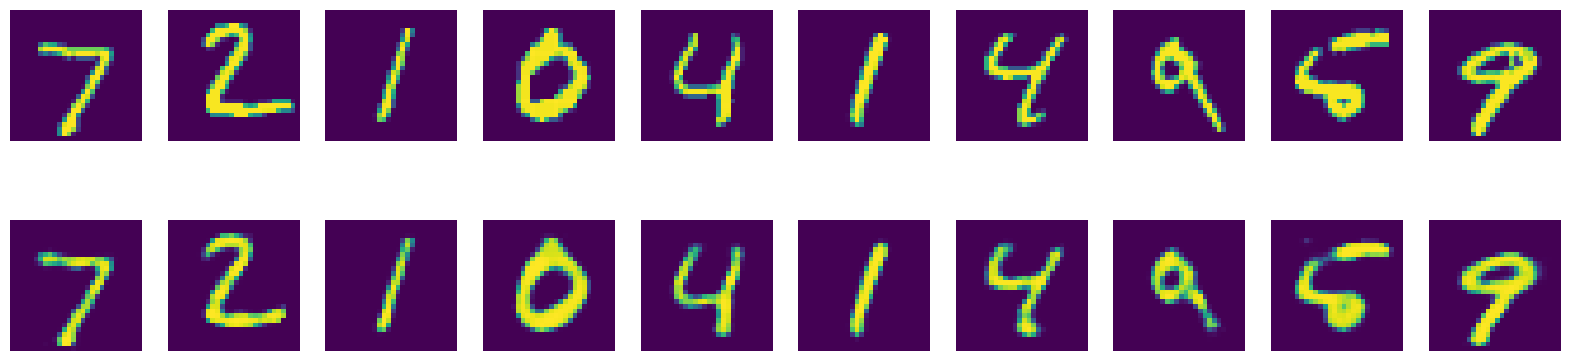

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
for i in range(10):
    plt.subplot(1, 10, ( i + 1))
    plt.imshow(x_test_scaled[i])
    plt.axis('off')

    plt.subplot(2, 10, ( i + 1 + 10))
    plt.imshow(pred[i])

    plt.axis('off')

---

In [33]:
import tensorflow as tf

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train.shape, x_test.shape, 

((60000, 28, 28), (10000, 28, 28))

In [34]:
# 정규화 

x_train_scaled = x_train / 255.0
x_test_scaled = x_test / 255.0

In [35]:
x_train_scaled = x_train_scaled.reshape(60000, 28, 28, -1)
x_test_scaled = x_test_scaled.reshape(-1, 28, 28, 1)
x_train_scaled.shape, x_test_scaled.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [40]:
model = tf.keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(filters=32, kernel_size=(2,2), strides=(2,2), activation="relu"),
    layers.Conv2D(filters=64, kernel_size=(2,2), strides=(2,2), activation="relu"),

    layers.Flatten(),
    layers.Dense(units=64, activation="elu"),
    layers.Dense(units=7*7*64),

    layers.Reshape(target_shape=(7, 7, 64)),
    layers.Conv2DTranspose(filters=32, kernel_size=(2, 2), strides=(2,2), activation="relu", padding="same"),
    layers.Conv2DTranspose(filters=1, kernel_size=(2, 2), strides=(2,2), activation="sigmoid", padding="same"),
])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │         8,224 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │           129 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,377 (1.61 MB)

 Trainable params: 421,377 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# 회귀모델 컴파일
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [42]:
model.fit(x_train_scaled, x_train_scaled, epochs=30)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0202 - mae: 0.0521
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0083 - mae: 0.0286
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0070 - mae: 0.0253
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0061 - mae: 0.0230
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0055 - mae: 0.0216
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0050 - mae: 0.0201
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0047 - mae: 0.0194
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0042 - mae: 0.0187
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0038 - mae: 0.0180
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0036 - mae: 0.0175
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0035 - mae: 0.0172
Epoch 12/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0032 

In [43]:
from sklearn.metrics import r2_score

pred = model.predict(x_test_scaled)

r2 = r2_score(x_test_scaled.reshape(784, -1), pred.reshape(784,-1))
r2

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0.978019958270988

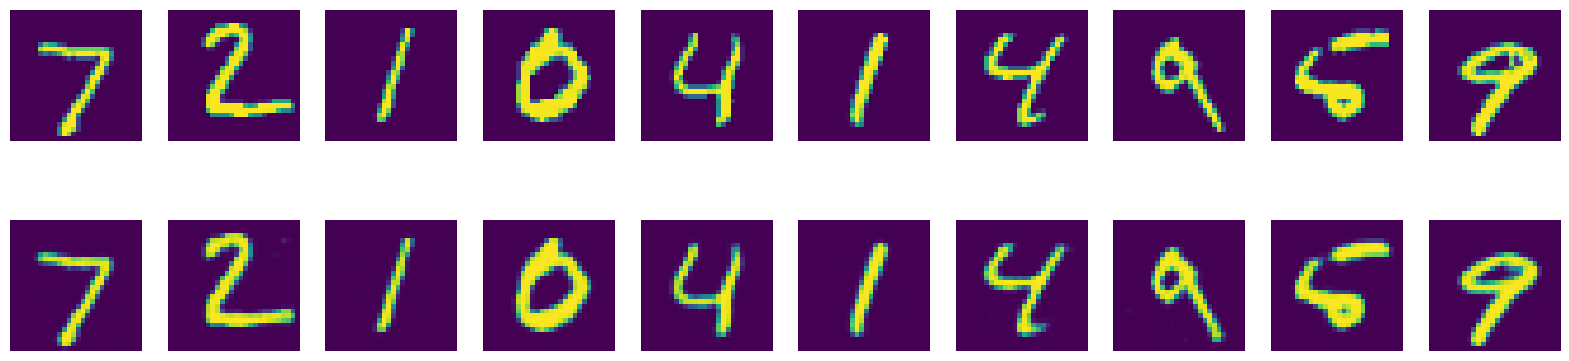

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
for i in range(10):
    plt.subplot(1, 10, ( i + 1))
    plt.imshow(x_test_scaled[i].reshape(28,28))
    plt.axis('off')

    plt.subplot(2, 10, ( i + 1 + 10))
    plt.imshow(pred[i].reshape(28,28))

    plt.axis('off')

---

In [68]:
import tensorflow as tf

# (x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(60000, 28, 28, -1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape, x_test.shape)
print(isinstance(x_train, np.ndarray))

(60000, 28, 28, 1) (10000, 28, 28, 1)
True


In [69]:
import numpy as np
x_train_noisy = x_train + 0.1 * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + 0.1 * tf.random.normal(shape=x_test.shape)

print(np.max(x_train_noisy), np.min(x_train_noisy), np.max(x_test_noisy), np.min(x_test_noisy))
print(x_train_noisy.shape, x_test_noisy.shape)
print(isinstance(x_train_noisy, np.ndarray))

1.4974395 -0.5410342 1.422411 -0.54815054
(60000, 28, 28, 1) (10000, 28, 28, 1)
False


In [70]:
x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0, clip_value_max=1)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0, clip_value_max=1)
np.max(x_train_noisy), np.min(x_train_noisy), np.max(x_test_noisy), np.min(x_test_noisy)
print(isinstance(x_train_noisy, np.ndarray))

False


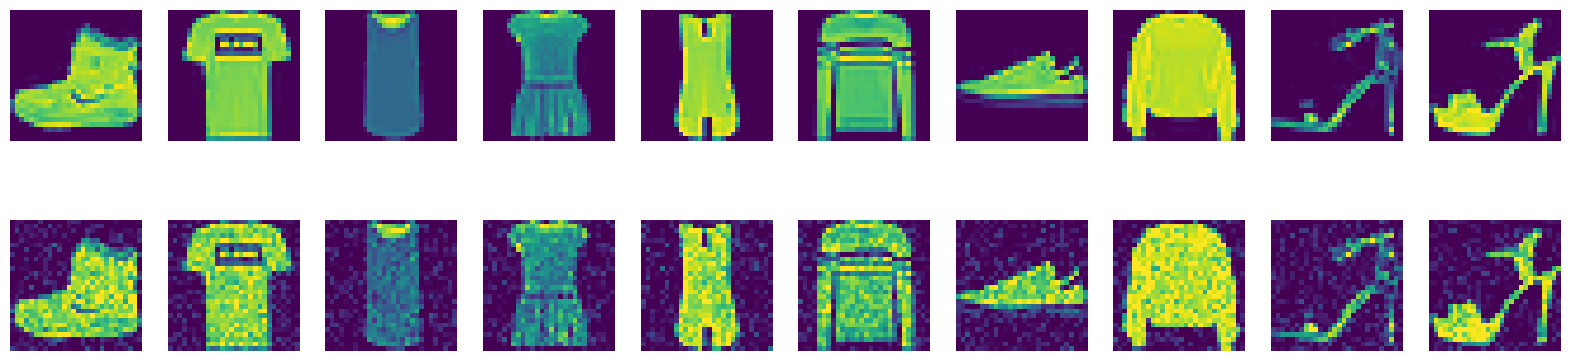

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
for i in range(10):
    plt.subplot(1, 10, ( i + 1))
    plt.imshow(x_train[i].reshape(28,28))
    plt.axis('off')

    plt.subplot(2, 10, ( i + 1 + 10))
    plt.imshow(x_train_noisy[i].numpy().reshape(28,28))

    plt.axis('off')

In [74]:
model_for_clothing = tf.keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(filters=32, kernel_size=(2,2), strides=(2,2), activation="relu"),
    layers.Conv2D(filters=64, kernel_size=(2,2), strides=(2,2), activation="relu"),

    layers.Flatten(),
    layers.Dense(units=64, activation="elu"),
    layers.Dense(units=7*7*64),

    layers.Reshape(target_shape=(7, 7, 64)),
    layers.Conv2DTranspose(filters=32, kernel_size=(2, 2), strides=(2,2), activation="relu", padding="same"),
    layers.Conv2DTranspose(filters=1, kernel_size=(2, 2), strides=(2,2), activation="sigmoid", padding="same"),
])

model_for_clothing.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 32)     │         8,224 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │           129 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,377 (1.61 MB)

 Trainable params: 421,377 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
model_for_clothing.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [81]:
model_for_clothing.fit(x_train_noisy, x_train, epochs=30)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0190 - mae: 0.0747
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0106 - mae: 0.0530
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0096 - mae: 0.0500
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0091 - mae: 0.0483
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 0.0086 - mae: 0.0469
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0083 - mae: 0.0457
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - loss: 0.0079 - mae: 0.0447
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.0077 - mae: 0.0439
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.0075 - mae: 0.0433
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.0074 - mae: 0.0428
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.0072 - mae: 0.0423
Epoch 12/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.007

In [83]:
from sklearn.metrics import r2_score

pred = model_for_clothing.predict(x_test_noisy)

r2 = r2_score(x_test.reshape(784, -1), pred.reshape(784,-1))
r2

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0.9504578770697127

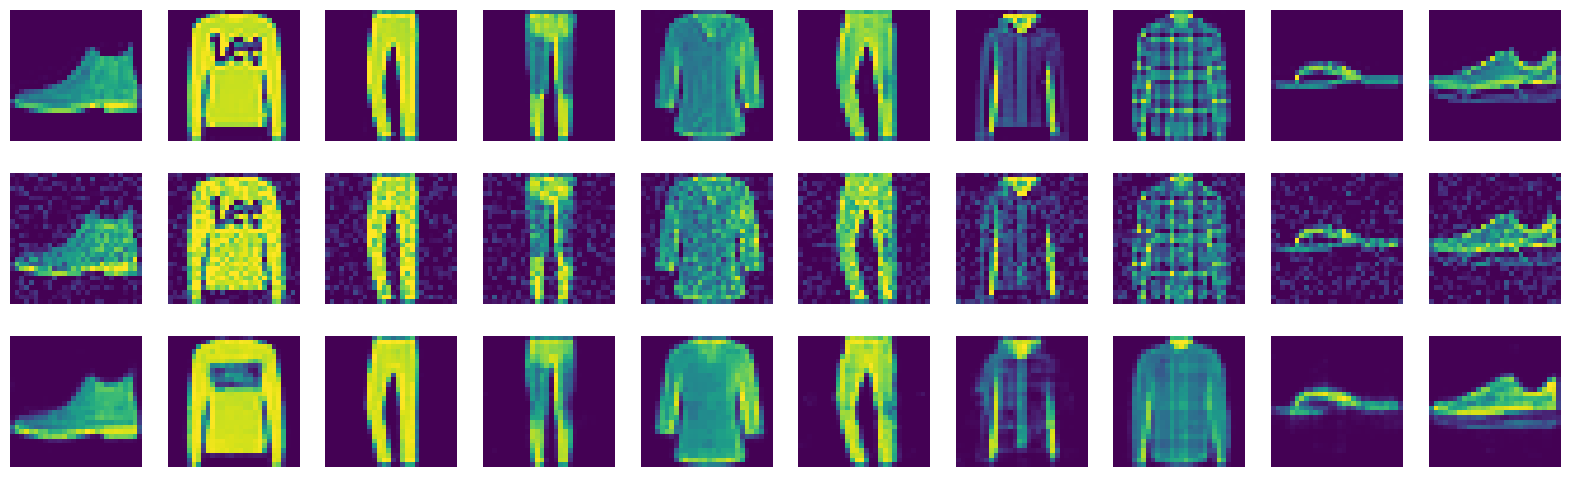

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
for i in range(10):
    plt.subplot(3, 10, ( i + 1))
    plt.imshow(x_test[i])
    plt.axis('off')

    plt.subplot(3, 10, ( i + 1 + 10))
    plt.imshow(x_test_noisy[i])
    plt.axis('off')

    plt.subplot(3, 10, ( i + 1 + 20))
    plt.imshow(pred[i].reshape(28, 28))
    plt.axis('off')